In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "credit_default_clean.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

df.head()

Dataset shape: (30000, 25)
Missing values: 0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
# Target distribution

target_summary = (
    df["TARGET"]
    .value_counts()
    .sort_index()
    .rename_axis("TARGET")
    .reset_index(name="Customers")
)

target_summary["Percent"] = (
    target_summary["Customers"] / len(df) * 100
).round(2)

target_summary

,TARGET,Customers,Percent
0,0,23364,77.88
1,1,6636,22.12


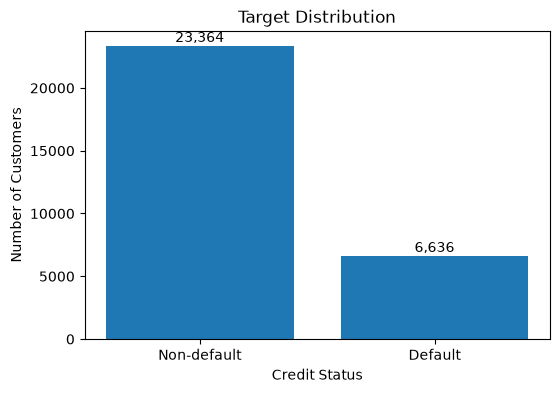

In [7]:
# Target distribution chart

target_labels = ["Non-default", "Default"]
target_counts = df["TARGET"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(target_labels, target_counts.values)

plt.title("Target Distribution")
plt.ylabel("Number of Customers")
plt.xlabel("Credit Status")

for i, value in enumerate(target_counts.values):
    plt.text(i, value + 300, f"{value:,}", ha="center")

plt.show()

### Insight

The dataset is moderately imbalanced:

- Non-default customers: 77.88%
- Default customers: 22.12%

Because the majority class is much larger than the default class, model evaluation should focus on metrics such as Recall, Precision, F1, ROC-AUC and PR-AUC rather than Accuracy alone.

In [8]:
demographic_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

for col in demographic_cols:
    summary = (
        df.groupby(col)["TARGET"]
        .agg(
            Customers="count",
            Defaults="sum",
            Default_Rate="mean"
        )
        .reset_index()
    )

    summary["Default_Rate"] = (
        summary["Default_Rate"] * 100
    ).round(2)

    print(f"\n===== {col} =====")
    print(summary)


===== SEX =====
   SEX  Customers  Defaults  Default_Rate
0    1      11888      2873         24.17
1    2      18112      3763         20.78

===== EDUCATION =====
   EDUCATION  Customers  Defaults  Default_Rate
0          1      10585      2036         19.23
1          2      14030      3330         23.73
2          3       4917      1237         25.16
3          4        468        33          7.05

===== MARRIAGE =====
   MARRIAGE  Customers  Defaults  Default_Rate
0         1      13659      3206         23.47
1         2      15964      3341         20.93
2         3        377        89         23.61


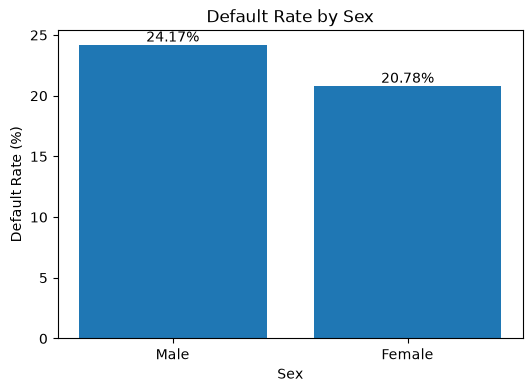

In [9]:
sex_summary = (
    df.groupby("SEX")["TARGET"]
    .mean()
    .mul(100)
)

sex_labels = ["Male", "Female"]

plt.figure(figsize=(6, 4))
plt.bar(sex_labels, sex_summary.values)

plt.title("Default Rate by Sex")
plt.ylabel("Default Rate (%)")
plt.xlabel("Sex")

for i, value in enumerate(sex_summary.values):
    plt.text(i, value + 0.3, f"{value:.2f}%", ha="center")

plt.show()

### Demographic EDA Insights

- Observed default rates differ across demographic groups.
- In this dataset, SEX=1 has a higher observed default rate than SEX=2.
- Default rate increases from graduate school to university and high school groups.
- The EDUCATION=4 and MARRIAGE=3 groups have relatively small sample sizes, so their rates should be interpreted cautiously.
- Demographic variables will be treated carefully and should not be used blindly for lending decisions.

In [10]:
# Create age groups for EDA

age_bins = [20, 29, 39, 49, 59, 100]
age_labels = ["21-29", "30-39", "40-49", "50-59", "60+"]

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=age_bins,
    labels=age_labels
)

age_summary = (
    df.groupby("AGE_GROUP", observed=False)["TARGET"]
    .agg(
        Customers="count",
        Defaults="sum",
        Default_Rate="mean"
    )
    .reset_index()
)

age_summary["Default_Rate"] = (
    age_summary["Default_Rate"] * 100
).round(2)

age_summary

,AGE_GROUP,Customers,Defaults,Default_Rate
0,21-29,9618,2197,22.84
1,30-39,11238,2276,20.25
2,40-49,6464,1485,22.97
3,50-59,2341,582,24.86
4,60+,339,96,28.32


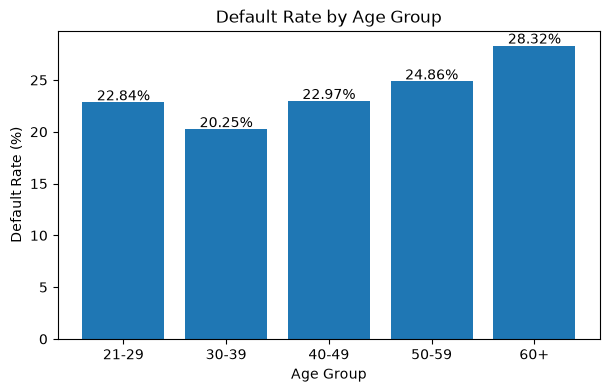

In [11]:
plt.figure(figsize=(7, 4))

plt.bar(
    age_summary["AGE_GROUP"].astype(str),
    age_summary["Default_Rate"]
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

for i, value in enumerate(age_summary["Default_Rate"]):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.show()

In [12]:
# Credit limit groups

df["LIMIT_GROUP"] = pd.cut(
    df["LIMIT_BAL"],
    bins=[0, 50000, 100000, 200000, 500000, float("inf")],
    labels=[
        "<=50K",
        "50K-100K",
        "100K-200K",
        "200K-500K",
        ">500K"
    ],
    include_lowest=True
)

limit_summary = (
    df.groupby("LIMIT_GROUP", observed=False)["TARGET"]
    .agg(
        Customers="count",
        Defaults="sum",
        Default_Rate="mean"
    )
    .reset_index()
)

limit_summary["Default_Rate"] = (
    limit_summary["Default_Rate"] * 100
).round(2)

limit_summary

,LIMIT_GROUP,Customers,Defaults,Default_Rate
0,<=50K,7676,2440,31.79
1,50K-100K,4822,1244,25.80
2,100K-200K,7880,1535,19.48
3,200K-500K,9416,1394,14.80
4,>500K,206,23,11.17


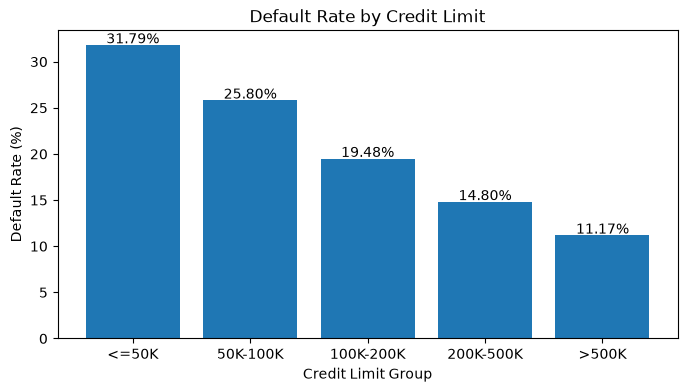

In [13]:
plt.figure(figsize=(8, 4))

plt.bar(
    limit_summary["LIMIT_GROUP"].astype(str),
    limit_summary["Default_Rate"]
)

plt.title("Default Rate by Credit Limit")
plt.xlabel("Credit Limit Group")
plt.ylabel("Default Rate (%)")

for i, value in enumerate(limit_summary["Default_Rate"]):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.show()

In [14]:
payment_status_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

# Không sửa các cột PAY gốc.
# Chỉ tạo bản dùng cho EDA:
# PAY <= 0 được coi là 0 tháng chậm khi tính delinquency.

pay_delay = df[payment_status_cols].clip(lower=0)

df["DELAYED_MONTHS"] = (pay_delay > 0).sum(axis=1)
df["MAX_DELAY"] = pay_delay.max(axis=1)
df["AVG_DELAY"] = pay_delay.mean(axis=1)

df[
    [
        "PAY_0", "PAY_2", "PAY_3",
        "PAY_4", "PAY_5", "PAY_6",
        "DELAYED_MONTHS", "MAX_DELAY", "AVG_DELAY",
        "TARGET"
    ]
].head()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,DELAYED_MONTHS,MAX_DELAY,AVG_DELAY,TARGET
0,2,2,-1,-1,-2,-2,2,2,0.666667,1
1,-1,2,0,0,0,2,2,2,0.666667,1
2,0,0,0,0,0,0,0,0,0.000000,0
3,0,0,0,0,0,0,0,0,0.000000,0
4,-1,0,-1,0,0,0,0,0,0.000000,0


In [15]:
delay_month_summary = (
    df.groupby("DELAYED_MONTHS")["TARGET"]
    .agg(
        Customers="count",
        Defaults="sum",
        Default_Rate="mean"
    )
    .reset_index()
)

delay_month_summary["Default_Rate"] = (
    delay_month_summary["Default_Rate"] * 100
).round(2)

delay_month_summary

,DELAYED_MONTHS,Customers,Defaults,Default_Rate
0,0,19931,2334,11.71
1,1,4426,1320,29.82
2,2,1899,736,38.76
3,3,1154,587,50.87
4,4,951,545,57.31
5,5,298,171,57.38
6,6,1341,943,70.32


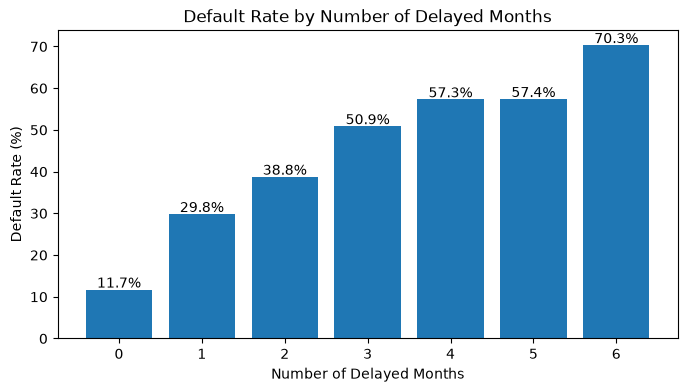

In [16]:
plt.figure(figsize=(8, 4))

plt.bar(
    delay_month_summary["DELAYED_MONTHS"].astype(str),
    delay_month_summary["Default_Rate"]
)

plt.title("Default Rate by Number of Delayed Months")
plt.xlabel("Number of Delayed Months")
plt.ylabel("Default Rate (%)")

for i, value in enumerate(delay_month_summary["Default_Rate"]):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [17]:
max_delay_summary = (
    df.groupby("MAX_DELAY")["TARGET"]
    .agg(
        Customers="count",
        Defaults="sum",
        Default_Rate="mean"
    )
    .reset_index()
)

max_delay_summary["Default_Rate"] = (
    max_delay_summary["Default_Rate"] * 100
).round(2)

max_delay_summary

,MAX_DELAY,Customers,Defaults,Default_Rate
0,0,19931,2334,11.71
1,1,1689,422,24.99
2,2,7187,3130,43.55
3,3,789,491,62.23
4,4,218,140,64.22
5,5,69,35,50.72
6,6,25,14,56.00
7,7,67,56,83.58
8,8,25,14,56.00


### Payment History Insights

- Payment behavior is strongly associated with default risk.
- Customers with no positive payment delay had an observed default rate of 11.71%.
- Default rate increased steadily as the number of delayed months increased.
- Customers delayed in all 6 observed months had a default rate of 70.32%.
- Maximum payment delay also showed a strong relationship with default risk.
- Very high MAX_DELAY groups contain small sample sizes, so their default rates should be interpreted cautiously.
- Payment persistence may be more stable and informative than using only a single month's payment status.

In [18]:
bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

payment_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)

df["AVG_PAY_AMT"] = df[payment_cols].mean(axis=1)

df[
    [
        "LIMIT_BAL",
        "AVG_BILL_AMT",
        "AVG_PAY_AMT",
        "TARGET"
    ]
].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.00,50000.00,140000.00,240000.00,1000000.00
AVG_BILL_AMT,30000.0,44976.95,63260.72,-56043.17,4781.33,21051.83,57104.42,877313.83
AVG_PAY_AMT,30000.0,5275.23,10137.95,0.00,1113.29,2397.17,5583.92,627344.33
TARGET,30000.0,0.22,0.42,0.00,0.00,0.00,0.00,1.00


In [22]:
df["CREDIT_UTILIZATION"] = (
    df["AVG_BILL_AMT"] / df["LIMIT_BAL"]
)

In [23]:
df[
    [
        "LIMIT_BAL",
        "AVG_BILL_AMT",
        "AVG_PAY_AMT",
        "CREDIT_UTILIZATION"
    ]
].head(10)

,LIMIT_BAL,AVG_BILL_AMT,AVG_PAY_AMT,CREDIT_UTILIZATION
0,20000,1284.000000,114.833333,0.064200
1,120000,2846.166667,833.333333,0.023718
2,90000,16942.166667,1836.333333,0.188246
3,50000,38555.666667,1398.000000,0.771113
4,50000,18223.166667,9841.500000,0.364463
5,50000,39685.666667,1295.333333,0.793713
6,500000,454099.166667,30126.500000,0.908198
7,100000,2247.666667,798.500000,0.022477
8,140000,10868.666667,1126.833333,0.077633
9,20000,4486.500000,2354.833333,0.224325


In [24]:
df["CREDIT_UTILIZATION_EDA"] = (
    df["CREDIT_UTILIZATION"]
    .clip(lower=0, upper=3)
)

df[
    [
        "AVG_BILL_AMT",
        "AVG_PAY_AMT",
        "CREDIT_UTILIZATION",
        "CREDIT_UTILIZATION_EDA"
    ]
].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
AVG_BILL_AMT,30000.0,44976.945,63260.722,-56043.167,4781.333,21051.833,57104.417,877313.833
AVG_PAY_AMT,30000.0,5275.232,10137.946,0.000,1113.292,2397.167,5583.917,627344.333
CREDIT_UTILIZATION,30000.0,0.373,0.352,-0.233,0.030,0.285,0.688,5.364
CREDIT_UTILIZATION_EDA,30000.0,0.373,0.351,0.000,0.030,0.285,0.688,3.000


In [25]:
df["UTILIZATION_GROUP"] = pd.cut(
    df["CREDIT_UTILIZATION_EDA"],
    bins=[
        -0.001,
        0.25,
        0.50,
        0.75,
        1.00,
        float("inf")
    ],
    labels=[
        "0-25%",
        "25-50%",
        "50-75%",
        "75-100%",
        ">100%"
    ]
)

util_summary = (
    df.groupby(
        "UTILIZATION_GROUP",
        observed=False
    )["TARGET"]
    .agg(
        Customers="count",
        Defaults="sum",
        Default_Rate="mean"
    )
    .reset_index()
)

util_summary["Default_Rate"] = (
    util_summary["Default_Rate"] * 100
).round(2)

util_summary

,UTILIZATION_GROUP,Customers,Defaults,Default_Rate
0,0-25%,14386,2585,17.97
1,25-50%,4555,905,19.87
2,50-75%,4878,1224,25.09
3,75-100%,5544,1704,30.74
4,>100%,637,218,34.22


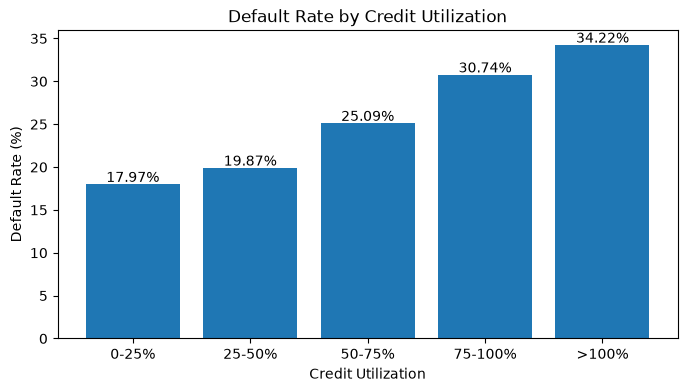

In [26]:
plt.figure(figsize=(8, 4))

plt.bar(
    util_summary["UTILIZATION_GROUP"].astype(str),
    util_summary["Default_Rate"]
)

plt.title("Default Rate by Credit Utilization")
plt.xlabel("Credit Utilization")
plt.ylabel("Default Rate (%)")

for i, value in enumerate(util_summary["Default_Rate"]):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [27]:
df["PAYMENT_TO_BILL"] = np.where(
    df["AVG_BILL_AMT"] > 0,
    df["AVG_PAY_AMT"] / df["AVG_BILL_AMT"],
    np.nan
)

df[
    [
        "AVG_BILL_AMT",
        "AVG_PAY_AMT",
        "PAYMENT_TO_BILL"
    ]
].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
AVG_BILL_AMT,30000.0,44976.945,63260.722,-56043.167,4781.333,21051.833,57104.417,877313.833
AVG_PAY_AMT,30000.0,5275.232,10137.946,0.000,1113.292,2397.167,5583.917,627344.333
PAYMENT_TO_BILL,28929.0,0.487,5.607,0.000,0.043,0.095,0.623,797.000


In [28]:
df["PAYMENT_TO_BILL_EDA"] = (
    df["PAYMENT_TO_BILL"]
    .clip(lower=0, upper=2)
)

df["PAYMENT_RATIO_GROUP"] = pd.cut(
    df["PAYMENT_TO_BILL_EDA"],
    bins=[
        -0.001,
        0.10,
        0.25,
        0.50,
        1.00,
        float("inf")
    ],
    labels=[
        "0-10%",
        "10-25%",
        "25-50%",
        "50-100%",
        ">100%"
    ]
)

payment_ratio_summary = (
    df.dropna(subset=["PAYMENT_RATIO_GROUP"])
    .groupby(
        "PAYMENT_RATIO_GROUP",
        observed=False
    )["TARGET"]
    .agg(
        Customers="count",
        Defaults="sum",
        Default_Rate="mean"
    )
    .reset_index()
)

payment_ratio_summary["Default_Rate"] = (
    payment_ratio_summary["Default_Rate"] * 100
).round(2)

payment_ratio_summary

,PAYMENT_RATIO_GROUP,Customers,Defaults,Default_Rate
0,0-10%,14722,3971,26.97
1,10-25%,3347,662,19.78
2,25-50%,2596,383,14.75
3,50-100%,5338,826,15.47
4,>100%,2926,426,14.56


## EDA Summary

Key findings from exploratory analysis:

- The target is moderately imbalanced:
  - Non-default: 77.88%
  - Default: 22.12%

- Payment history is strongly associated with default risk.
- Customers with no positive delay had an observed default rate of 11.71%.
- Customers delayed in all 6 observed months had an observed default rate of 70.32%.
- Maximum payment delay also showed a strong relationship with default risk.
- Credit utilization showed meaningful differences in default behavior across utilization groups.
- Customers with very low Payment-to-Bill ratios had substantially higher default rates:
  - 0–10% payment ratio: 26.97%
  - 25–50% payment ratio: 14.75%
  - >100% payment ratio: 14.56%

These results suggest that repayment behavior, payment persistence, and credit utilization are likely to be important predictive features for default modeling.